--- Phase de Calibration avec MPQP ---
Matrice de Calibration M (mesurée expérimentalement) :
[[0.72 0.08 0.08 0.01]
 [0.13 0.02 0.76 0.09]
 [0.13 0.76 0.02 0.09]
 [0.02 0.14 0.14 0.81]]


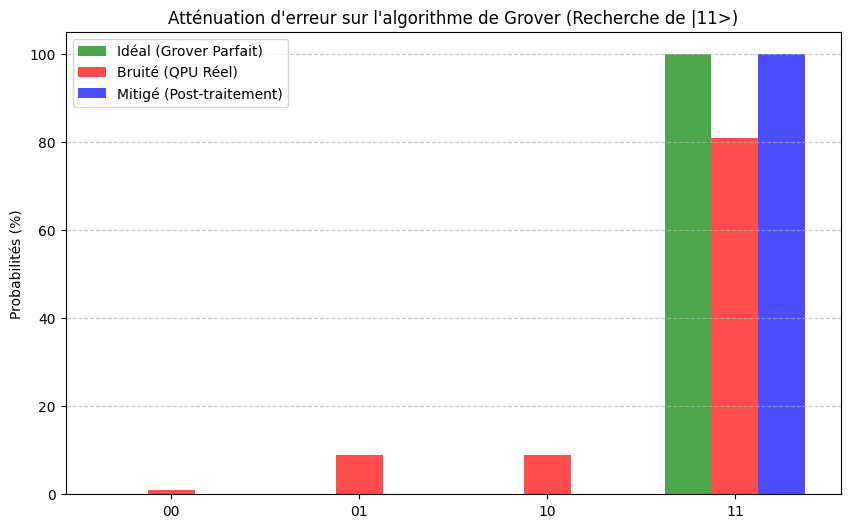

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. IMPORTATIONS CORRIGÉES MPQP (Utilisation de CNOT au lieu de CX)
from mpqp import QCircuit, BasisMeasure
from mpqp.gates import H, X, CNOT
from mpqp.execution import run, IBMDevice

# ==========================================
# 2. FONCTIONS DE SIMULATION ET DE BRUIT
# ==========================================

def get_ideal_probabilities(circuit, num_qubits=2):
    """
    Exécute un circuit MPQP sur le simulateur local idéal et renvoie les probabilités.
    """
    # Exécution locale avec le simulateur AER (pas besoin de compte IBM)
    result = run(circuit, IBMDevice.AER_SIMULATOR)
    probs = result.probabilities

    # Sécurité : MPQP renvoie souvent une liste/array, mais si c'est un dict, on le convertit
    if isinstance(probs, dict):
        vec = np.zeros(2**num_qubits)
        for state, prob in probs.items():
            idx = int(state, 2)
            vec[idx] = prob
        return vec

    # On s'assure d'avoir la bonne taille (tronquer si le simulateur renvoie trop de zéros)
    return np.array(probs)[:2**num_qubits]

# --- MODÉLISATION DU BRUIT (Physique matérielle) ---
# Le capteur physique lit "1" au lieu de "0" dans 15% des cas, et "0" au lieu de "1" dans 10% des cas
p0_to_1 = 0.15
p1_to_0 = 0.10

# Matrice d'erreur pour 1 qubit
E_1q = np.array([[1 - p0_to_1, p1_to_0],
                 [p0_to_1,     1 - p1_to_0]])

# Matrice d'erreur pour 2 qubits (Produit Tensoriel : effet sur tout le système)
HARDWARE_NOISE_MATRIX = np.kron(E_1q, E_1q)

def apply_hardware_noise(ideal_vec):
    """Applique le bruit matériel au vecteur de probabilités idéal."""
    return np.dot(HARDWARE_NOISE_MATRIX, ideal_vec)


# ==========================================
# 3. L'EXPÉRIENCE : ALGORITHME DE GROVER (Recherche de l'état |11>)
# ==========================================
# Création du circuit MPQP avec la bonne dimension
qc = QCircuit(2)

# Étape 1 : Superposition initiale
qc.add(H(0))
qc.add(H(1))

# Étape 2 : L'ORACLE (Marque l'état |11> avec une phase négative)
# On utilise une porte CZ (Control-Z), construite avec CNOT encadré de H
qc.add(H(1))
qc.add(CNOT(0, 1))
qc.add(H(1))

# Étape 3 : LE DIFFUSEUR (Amplification d'amplitude vers la bonne réponse)
qc.add(H(0))
qc.add(H(1))
qc.add(X(0))
qc.add(X(1))
# Porte CZ centrale du diffuseur
qc.add(H(1))
qc.add(CNOT(0, 1))
qc.add(H(1))
# Fin du diffuseur
qc.add(X(0))
qc.add(X(1))
qc.add(H(0))
qc.add(H(1))

qc.add(BasisMeasure()) # Mesure globale

# Récupération des résultats idéaux puis application du bruit matériel
vec_ideal = get_ideal_probabilities(qc)
vec_noisy = apply_hardware_noise(vec_ideal)


# ==========================================
# 4. ATTÉNUATION CLASSIQUE (Readout Error Mitigation)
# ==========================================
print("--- Phase de Calibration avec MPQP ---")

M = np.zeros((4, 4))
states = ['00', '01', '10', '11']

for j, state in enumerate(states):
    qc_cal = QCircuit(2)

    # Préparation de l'état
    if state[1] == '1': qc_cal.add(X(0))
    if state[0] == '1': qc_cal.add(X(1))

    qc_cal.add(BasisMeasure())

    # On exécute le circuit pur, et le capteur (bruit) fausse la lecture
    ideal_cal = get_ideal_probabilities(qc_cal)
    M[:, j] = apply_hardware_noise(ideal_cal)

print("Matrice de Calibration M (mesurée expérimentalement) :")
print(np.round(M, 2))

# L'ORDINATEUR CLASSIQUE PREND LE RELAIS : Inversion de la Matrice
M_inv = np.linalg.inv(M)

# Application de la correction sur nos résultats initiaux bruités
vec_mitigated = np.dot(M_inv, vec_noisy)

# Nettoyage classique des probabilités négatives
vec_mitigated[vec_mitigated < 0] = 0
vec_mitigated = vec_mitigated / np.sum(vec_mitigated)


# ==========================================
# 5. AFFICHAGE DES RÉSULTATS
# ==========================================
x = np.arange(4)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, vec_ideal * 100, width, label='Idéal (Grover Parfait)', color='green', alpha=0.7)
ax.bar(x, vec_noisy * 100, width, label='Bruité (QPU Réel)', color='red', alpha=0.7)
ax.bar(x + width, vec_mitigated * 100, width, label='Mitigé (Post-traitement)', color='blue', alpha=0.7)

ax.set_ylabel('Probabilités (%)')
ax.set_title("Atténuation d'erreur sur l'algorithme de Grover (Recherche de |11>)")
ax.set_xticks(x)
ax.set_xticklabels(states)
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Grover's algorithm for any size of input

In [2]:
pip install mpqp

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [3]:
from mpqp import*
from mpqp.gates import*
from mpqp.measures import BasisMeasure
from mpqp.execution import*

import math
import random
import matplotlib.pyplot as plt

def multiTOF(circuit : QCircuit, control_qubits : list[int], work_qubits : list[int], target : int):
    assert len(control_qubits) >= 2, "A tofoli gate requires at least 2 control qubits";

    if len(work_qubits) == 0:
        assert len(control_qubits) == 2, f"If no work qubits given, there must be 2 control qubits. There are {len(control_qubits)} control qubits, so there should be {len(control_qubits) -1} work qubits."
        circuit.add(TOF([0,1],target))
        return

    assert len(work_qubits) == len(control_qubits) -1, f"wrong number of work qubits, should be {len(control_qubits) -1} instead of {len(work_qubits)}"

    qubits = control_qubits + work_qubits + [target]

    def _multiTOF(circuit : QCircuit,work_qubits : int):
        if work_qubits == 0:
            return

        def _mutliTOFLeft(circuit : QCircuit,depth : int, work_qubits : int):
            if depth == 0:
                return
            if depth == 1:
                circuit.add(TOF([qubits[0],qubits[1]],qubits[work_qubits+1]))
                return

            _mutliTOFLeft(circuit,depth-1,work_qubits)
            circuit.add(TOF([qubits[depth + work_qubits -1],qubits[depth]],qubits[depth + work_qubits]))

        def _mutliTOFRight(circuit : QCircuit,depth : int, work_qubits : int):
            if depth == 0:
                return
            if depth == 1:
                circuit.add(TOF([qubits[0],qubits[1]],qubits[work_qubits+1]))
                return

            circuit.add(TOF([qubits[depth + work_qubits -1],qubits[depth]],qubits[depth + work_qubits]))
            _mutliTOFRight(circuit,depth-1,work_qubits)


        _mutliTOFLeft(circuit,len(work_qubits),len(work_qubits))
        circuit.add(CNOT(work_qubits[-1],target))
        _mutliTOFRight(circuit,len(work_qubits),len(work_qubits))
        return


    return _multiTOF(circuit,work_qubits)


if __name__ == "__main__":
    circuit = QCircuit(3)
    multiTOF(circuit,[0,1],[],2)
    circuit.pretty_print()


    circuit = QCircuit(8)
    multiTOF(circuit,[0,1,2,3],[4,5,6],7)
    circuit.pretty_print()

QCircuit : Size (Qubits, Cbits) = (3, 0), Nb instructions = 1
          
q_0: ──■──
       │  
q_1: ──■──
     ┌─┴─┐
q_2: ┤ X ├
     └───┘
QCircuit : Size (Qubits, Cbits) = (8, 0), Nb instructions = 7
                                        
q_0: ──■─────────────────────────────■──
       │                             │  
q_1: ──■─────────────────────────────■──
       │                             │  
q_2: ──┼────■───────────────────■────┼──
       │    │                   │    │  
q_3: ──┼────┼────■─────────■────┼────┼──
     ┌─┴─┐  │    │         │    │  ┌─┴─┐
q_4: ┤ X ├──■────┼─────────┼────■──┤ X ├
     └───┘┌─┴─┐  │         │  ┌─┴─┐└───┘
q_5: ─────┤ X ├──■─────────■──┤ X ├─────
          └───┘┌─┴─┐     ┌─┴─┐└───┘     
q_6: ──────────┤ X ├──■──┤ X ├──────────
               └───┘┌─┴─┐└───┘          
q_7: ───────────────┤ X ├───────────────
                    └───┘               


In [4]:
from mpqp import*
from mpqp.gates import*
from mpqp.measures import BasisMeasure
from mpqp.execution import*

import math
import random
import matplotlib.pyplot as plt


def add_diffusion(circuit : QCircuit, n : int, working_qubits : list[int]):
    circuit.add(Barrier())
    circuit.add([H(i) for i in range(n)])
    circuit.add(Barrier())

    circuit.add([X(i) for i in range(n)])

    circuit.add(H(n-1))
    multiTOF(circuit,[i for i in range(n-1)],working_qubits,n-1)
    circuit.add(H(n-1))

    circuit.add([X(i) for i in range(n)])

    circuit.add(Barrier())
    circuit.add([H(i) for i in range(n)])
    circuit.add(Barrier())



def add_oracle(circuit : QCircuit,n : int,searching : list, working_qubits : list[int]):
    circuit.add(Barrier())
    for i,q in enumerate(searching):
        if(q == 0):
            circuit.add(X(i))
    circuit.add(Barrier())

    circuit.add(H(n-1))
    multiTOF(circuit,[i for i in range(n-1)],working_qubits,n-1)
    circuit.add(H(n-1))
    circuit.add(Barrier())

    for i,q in enumerate(searching):
        if(q == 0):
            circuit.add(X(i))
    circuit.add(Barrier())

def number_anciliary_qubits(nb_reps : int, n : int):
    assert n >= 3 , "cannot apply Grover on less than 3 qubits"

    if n == 3 : return 0 #no need for extra qubits

    return (n-2) * nb_reps * 2 # *2 cuz we need a bunch for the Oracle and as many again for the diffusion



if __name__ == "__main__":
    n = 6 # number of qubits as inputs for the circuit
    domain_size = 2**n # usually noted N

    searching = [random.randint(0,1) for i in range(n)]

    print(f"searching : {searching}")

    assert len(searching) == n, f"should search a value of length {n}"


    #number of repetitions
    nb_reps = round(math.pi/4 * math.sqrt(domain_size))

    #number of anciliary qubits for multiTOF
    nb_anciliary = 0 if n == 3 else n-2
    anciliary = [n+i for i in range(nb_anciliary)]

    #circuit init
    circuit = QCircuit(n + nb_anciliary)
    circuit.add([H(i) for i in range(n)])


    for i in range(nb_reps):
        add_oracle(circuit,n,searching,anciliary)

        add_diffusion(circuit,n,anciliary)

    circuit.add(BasisMeasure([i for i in range(n)]))

    circuit.pretty_print()
    result = run(circuit,IBMDevice.AER_SIMULATOR)
    samples =  [s for s in result.samples if s.count > 0]
    samples.sort(key=lambda s : s.count,reverse=True)
    print(f" most common element is {samples[0].bin_str} with {samples[0].count} occurences ({samples[0].probability})")


searching : [0, 1, 0, 0, 1, 0]
QCircuit : Size (Qubits, Cbits) = (10, 6), Nb instructions = 379
     ┌───┐ ░ ┌───┐ ░                                                         ░ »
q_0: ┤ H ├─░─┤ X ├─░────────■────────────────────────────────────────────■───░─»
     ├───┤ ░ └───┘ ░        │                                            │   ░ »
q_1: ┤ H ├─░───────░────────■────────────────────────────────────────────■───░─»
     ├───┤ ░ ┌───┐ ░        │                                            │   ░ »
q_2: ┤ H ├─░─┤ X ├─░────────┼────■──────────────────────────────────■────┼───░─»
     ├───┤ ░ ├───┤ ░        │    │                                  │    │   ░ »
q_3: ┤ H ├─░─┤ X ├─░────────┼────┼────■────────────────────────■────┼────┼───░─»
     ├───┤ ░ └───┘ ░        │    │    │                        │    │    │   ░ »
q_4: ┤ H ├─░───────░────────┼────┼────┼────■─────────■─────────┼────┼────┼───░─»
     ├───┤ ░ ┌───┐ ░ ┌───┐  │    │    │    │  ┌───┐  │  ┌───┐  │    │    │   ░ »
q_5: ┤ H ├─░─

In [17]:
def run_grover(searching : list[int]) -> bool:
    n = len(searching) # number of qubits as inputs for the circuit
    domain_size = 2**n # usually noted N

    nb_reps = round(math.pi/4 * math.sqrt(domain_size))

    #number of anciliary qubits for multiTOF
    nb_anciliary = 0 if n == 3 else n-2
    anciliary = [n+i for i in range(nb_anciliary)]

    #circuit init
    circuit = QCircuit(n + nb_anciliary)
    circuit.add([H(i) for i in range(n)])

    for i in range(nb_reps):
        add_oracle(circuit,n,searching,anciliary)

        add_diffusion(circuit,n,anciliary)

    circuit.add(BasisMeasure([i for i in range(n)]))

    result = run(circuit,IBMDevice.AER_SIMULATOR)
    samples =  [s for s in result.samples if s.count > 0]
    samples.sort(key=lambda s : s.count,reverse=True)

    most_common = [int(d) for d in samples[0].bin_str]

    return most_common

if __name__ == "__main__":
    searching = [random.randint(0,1) for i in range(10)]

    result = run_grover(searching)

    print(f"ran grover, found {result}, which is {'correct' if result == searching else 'incorrect'}.")


ran grover, found [1, 1, 1, 0, 0, 1, 0, 1, 1, 1], which is correct.


In [31]:
from mpqp.noise import *

def run_grover_with_error(searching : list[int], error_prob : float = 0) -> bool:
    n = len(searching) # number of qubits as inputs for the circuit
    domain_size = 2**n # usually noted N

    nb_reps = round(math.pi/4 * math.sqrt(domain_size))

    #number of anciliary qubits for multiTOF
    nb_anciliary = 0 if n == 3 else n-2
    anciliary = [n+i for i in range(nb_anciliary)]

    #circuit init
    circuit = QCircuit(n + nb_anciliary)
    circuit.add([H(i) for i in range(n)])

    for i in range(nb_reps):
        add_oracle(circuit,n,searching,anciliary)

        add_diffusion(circuit,n,anciliary)


    circuit.add(BasisMeasure())
    circuit.add(BitFlip(error_prob,gates=[H]))

    result = run(circuit,IBMDevice.AER_SIMULATOR)
    samples =  [s for s in result.samples if s.count > 0]
    samples.sort(key=lambda s : s.count,reverse=True)

    most_common = [int(d) for d in samples[0].bin_str[:n]]

    return most_common

if __name__ == "__main__":
    searching = [random.randint(0,1) for i in range(5)]

    result = run_grover_with_error(searching,0.01)

    print(f"ran grover, found {result}, which is {'correct' if result == searching else 'incorrect'}.")


ran grover, found [1, 1, 0, 0, 1], which is correct.


In [42]:
import csv
import os

RESULTS_DIRECTORY = "NoiseResults"
os.makedirs(RESULTS_DIRECTORY,exist_ok=True)

n_values = [3, 4, 5,6]
errors = [0, 0.1, 0.2,0.3, 0.4, 0.5]
trials = 100

for n in n_values:
    filepath = f"grover_noise_results_n{n}.csv"
    if os.path.isfile(f"{RESULTS_DIRECTORY}/{filepath}"):
        print(f"file {filepath} already exists, skipping ...")
        continue

    success_rates = []
    for e in errors:
        correct = 0
        for i in range(trials):
            target = [random.randint(0, 1) for _ in range(n)]
            if target == run_grover_with_error(target, e):
                correct += 1
        rate = correct / trials
        success_rates.append(rate)
        print(f"[n={n}]error={e} → success rate: {rate:.2f}")


    with open(f"{RESULTS_DIRECTORY}/{filepath}", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["error_rate", "success_rate"])
        writer.writerows(zip(errors, success_rates))

    print(f"Saved to {RESULTS_DIRECTORY}/{filepath}")

file grover_noise_results_n3.csv already exists, skipping ...
file grover_noise_results_n4.csv already exists, skipping ...
file grover_noise_results_n5.csv already exists, skipping ...
file grover_noise_results_n6.csv already exists, skipping ...


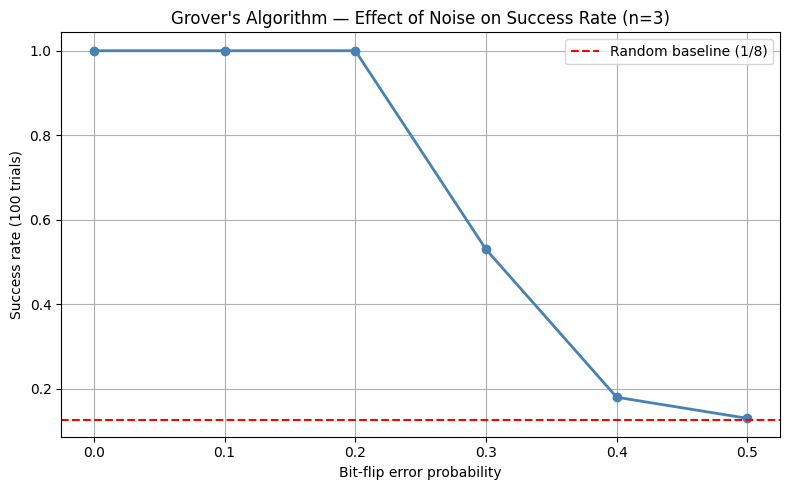

In [ ]:
import csv
import matplotlib.pyplot as plt

def plot_file(filepath : str,n : int):
    errors, success_rates = [], []
    with open(filepath, newline="") as f:
        for row in csv.DictReader(f):
            errors.append(float(row["error_rate"]))
            success_rates.append(float(row["success_rate"]))

    plt.figure(figsize=(8, 5))
    plt.plot(errors, success_rates, marker="o", color="steelblue", linewidth=2)
    plt.axhline(y=0.125, color="red", linestyle="--", label=f"Random baseline (1/{2**n})")
    plt.xlabel("Bit-flip error probability")
    plt.ylabel("Success rate (100 trials)")
    plt.title(f"Grover's Algorithm — Effect of Noise on Success Rate (n={n})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_file("NoiseResults/grover_noise_results_n3.csv",3)

In [ ]:
plot_file("NoiseResults/grover_noise_results_n3.csv",3)
plot_file("NoiseResults/grover_noise_results_n4.csv",4)
plot_file("NoiseResults/grover_noise_results_n5.csv",5)
plot_file("NoiseResults/grover_noise_results_n6.csv",6)